In [1]:
# =========================
# 1. Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import LabelEncoder

In [2]:
# =========================
# 2. Download NLTK Data
# =========================
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/yasir/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/yasir/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:

# =========================
# 3. Load Data
# =========================
df = pd.read_csv('email_intent.csv')

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

                                               email     intent
0  Is there any coupon available for loyal custom...    inquiry
1                    What are your office locations?    inquiry
2  I am writing to complain about the unacceptabl...  complaint
3  This delay in handling is frustrated, very dis...  complaint
4       Thank you for managing my complaint quickly.   feedback


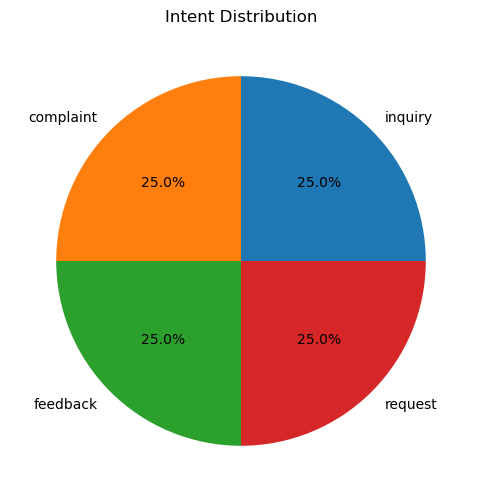

In [4]:

# =========================
# 4. Basic EDA
# =========================
print(df.head())

# Class distribution
values = df['intent'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(values, labels=values.index, autopct='%1.1f%%')
plt.title("Intent Distribution")
plt.show()

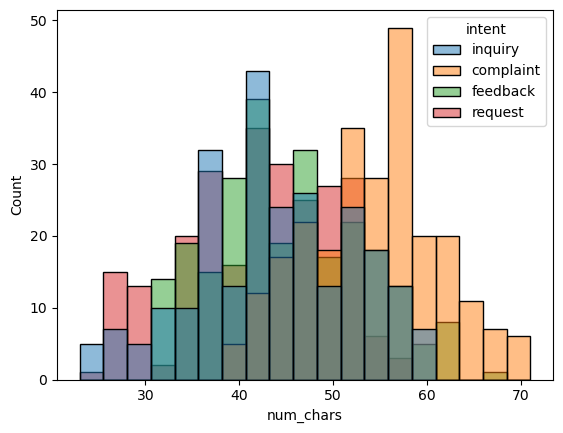

In [5]:

# =========================
# 5. Feature Engineering
# =========================
df['num_chars'] = df['email'].apply(len)
df['num_words'] = df['email'].apply(lambda x: len(nltk.word_tokenize(x)))

sns.histplot(data=df, x="num_chars", hue="intent")
plt.show()

In [6]:

# =========================
# 6. Label Encoding
# =========================
le = LabelEncoder()
df['intent'] = le.fit_transform(df['intent'])

In [7]:

# =========================
# 7. Text Preprocessing
# =========================
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_text(text):
    text = text.lower()
    words = nltk.word_tokenize(text)

    cleaned_words = []
    for word in words:
        if word.isalnum() and word not in stop_words:
            cleaned_words.append(ps.stem(word))

    return " ".join(cleaned_words)

df['transformed_text'] = df['email'].apply(transform_text)

In [8]:
# =========================
# 8. Train-Test Split (NO LEAKAGE)
# =========================
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['transformed_text'],
    df['intent'],
    test_size=0.2,
    random_state=42
)

In [9]:

# =========================
# 9. Pipeline (Clean Approach)
# =========================
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000)),
    ('model', MultinomialNB())
])

# Train
pipeline.fit(X_train_text, y_train)

# Predict
y_pred = pipeline.predict(X_test_text)

In [10]:

# =========================
# 10. Evaluation
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.985

Confusion Matrix:
 [[44  0  0  0]
 [ 0 59  0  0]
 [ 0  1 46  0]
 [ 0  0  2 48]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       0.98      1.00      0.99        59
           2       0.96      0.98      0.97        47
           3       1.00      0.96      0.98        50

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [11]:
# =========================
# 11. Test on Custom Input
# =========================
def predict_intent(text):
    processed = transform_text(text)
    pred = pipeline.predict([processed])[0]
    return le.inverse_transform([pred])[0]

In [14]:

# Example
test_email = "I'm not satisfied with customer support"
print("\nPrediction:", predict_intent(test_email))


Prediction: feedback
